# Reto 2 · EBM en CIBERESUCICOVID con dianas funcionales

**Notebook 07.** Modelo **solo con CIBERESUCICOVID**, la única cohorte con la fase aguda completa: **10 datos del alta + 20 de la fase aguda**, EBM. Pregunta: ¿mejora la fase aguda lo que se consigue al alta (notebook 06)?

| Diana | Definición | N |
|---|---|---|
| **A · Fenotipo funcional a 3 meses** | F2 «afectación funcional» frente a F1 «función conservada» (clustering común del notebook 04; la misma diana del notebook 06) | ≈ 956 |
| **B · DLCO baja a 12 meses** | DLCO < 80 % del predicho en la visita anual | ≈ 473 |

**Modelos comparados** (mismo test en cada diana):
- **EBM alta + aguda:** el principal.
- **EBM solo alta:** mide lo que aporta la fase aguda.
- **Regresión logística alta + aguda:** referencia.
- **Solo en B, EBM alta + aguda + función a 3 meses** (DLCO, FVC, FEV1): ¿cuánto se gana esperando a la primera visita? En A no se puede, porque esas variables definen el fenotipo (sería fuga).

**Validación:** partición 80/20 estratificada y validación agrupada por centro (centros no vistos).

> **Privacidad.** Solo agregados. Datasets y modelos en `Datos limpios/`, fuera del repositorio.

## 0 · Entorno y funciones

In [1]:
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix, precision_recall_curve,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, fenotipado_perfil as FP, privacidad

warnings.filterwarnings("ignore", category=UserWarning)
cfg = carga.cargar_config()
MC, MF = cfg["modelo_ciberes"], cfg["modelo_ciberes_funcional"]
SEMILLA = cfg["semilla"]
N_MIN = cfg["privacidad"]["n_minimo_celda"]
DATOS = carga.RAIZ / cfg["rutas"]["procesados"]
FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)
PFX = "07_ebm_func"
C_MOD = {"EBM alta + aguda": "#6a3d9a", "EBM solo alta": "#cab2d6", "Logística alta + aguda": "#999999",
         "EBM alta + aguda + función 3 m": "#e7298a"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)

ALTA = MC["predictores_alta"]
AGU_BIN, AGU_CONT = MC["predictores_agudos"]["binarias"], MC["predictores_agudos"]["continuas"]
F_ALTA = ALTA["continuas"] + ALTA["binarias"] + ALTA["categoricas"]
F_AGU = list(AGU_BIN) + list(AGU_CONT)
F_FUN = [f"{v}_T3" for v in MF["funcion_3m"]]
CONTINUAS = set(ALTA["continuas"]) | set(AGU_CONT) | set(F_FUN)
NOMBRES = {"edad": "Edad", "estancia_hosp_dias": "Estancia (días)", "sexo": "Sexo (mujer)", "nu_ingreso_uci": "UCI",
           "nu_hta": "HTA", "nu_diabetes": "Diabetes", "nu_card_cronica": "Cardiopatía", "nu_epoc": "EPOC",
           "nu_renal_cronica": "Enf. renal", "nu_tabaquismo": "Tabaquismo", "dlco_T3": "DLCO a 3 m",
           "fvc_T3": "FVC a 3 m", "fev1_T3": "FEV1 a 3 m", **AGU_BIN, **{k: v[0] for k, v in AGU_CONT.items()}}


def nota(fig, texto):
    fig.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")


def guardar(fig, nombre):
    fig.savefig(FIG / f"{PFX}_{nombre}.png", bbox_inches="tight", dpi=150)


def edad_aproximada(tramo):
    if not isinstance(tramo, str) or tramo.startswith("<"):
        return np.nan
    if tramo.endswith("+"):
        return float(tramo[:-1]) + 2
    lo, hi = tramo.split("-")
    return (float(lo) + float(hi)) / 2


def ic_bootstrap(y, p, metrica, n=MF["n_bootstrap_ic"], semilla=SEMILLA):
    rng = np.random.default_rng(semilla); vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) == 2:
            vals.append(metrica(y[idx], p[idx]))
    return tuple(np.percentile(vals, [2.5, 97.5]))


def dif_auc(y, p1, p2, n=MF["n_bootstrap_ic"], semilla=SEMILLA):
    rng = np.random.default_rng(semilla); difs = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) == 2:
            difs.append(roc_auc_score(y[idx], p1[idx]) - roc_auc_score(y[idx], p2[idx]))
    difs = np.array(difs)
    return roc_auc_score(y, p1) - roc_auc_score(y, p2), np.percentile(difs, [2.5, 97.5]), 2 * min((difs <= 0).mean(), (difs >= 0).mean())


def ebm_para(cols):
    return ExplainableBoostingClassifier(feature_names=[NOMBRES[c] for c in cols],
                                        feature_types=["continuous" if c in CONTINUAS else "nominal" for c in cols],
                                        random_state=SEMILLA, **MF["ebm"])


def logistica(cols):
    num = [c for c in cols if c not in ALTA["categoricas"]]
    return Pipeline([("prep", ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("esc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]),
         ALTA["categoricas"])])), ("lr", LogisticRegression(max_iter=5000, C=0.5))])

## 1 · Predictores y dianas

Limpieza de la fase aguda: código 2 → ausente y valores fuera del rango plausible → ausente; sin imputación.

In [2]:
base = pd.read_parquet(DATOS / MF["base"]).set_index("subject_id")
base = base[base["cohorte_analisis"] == "CIBERESUCICOVID"]
pacientes = pd.read_parquet(DATOS / "pacientes.parquet").set_index("subject_id")

X = pacientes.loc[base.index, ["centro_id", *[c for c in F_ALTA if c != "edad"]]].copy()
X["edad"] = pacientes.loc[base.index, "edad_tramo5"].map(edad_aproximada)
agudas = carga.cargar_columnas_completa(cfg, F_AGU).set_index("subject_id").reindex(base.index)
for v in AGU_BIN:
    agudas[v] = agudas[v].where(agudas[v].isin([0, 1]))
for v, (_, lo, hi) in AGU_CONT.items():
    agudas[v] = agudas[v].where(agudas[v].between(lo, hi))
X = X.join(agudas)

# Función pulmonar a 3 meses (solo para la variante de la diana B): misma construcción que el notebook 04
pf = FP.perfil(cfg, "fenotipado_comun")
medidas = pd.read_parquet(DATOS / "medidas.parquet")
t3, _ = FP.construir_variables(medidas, pacientes.reset_index(), cfg, pf, "H3", "CIBERESUCICOVID")
X = X.join(t3[F_FUN])

DIANAS = {}
for clave, col, positiva, desc in MF["dianas"]:
    y = base[col]
    ok = y.notna()
    DIANAS[clave] = {"desc": desc, "X": X[ok], "y": (y[ok] == positiva).astype(int).to_numpy()}
resumen = pd.DataFrame({k: {"descripción": v["desc"], "N": len(v["y"]), "% positivos": round(100 * v["y"].mean(), 1),
                            "% con función a 3 m": round(100 * v["X"][F_FUN[0]].notna().mean(), 1)}
                        for k, v in DIANAS.items()}).T
pd.concat([X.assign(**{f"y_{k}": pd.Series(v["y"], index=v["X"].index) for k, v in DIANAS.items()})]).reset_index() \
    .to_parquet(DATOS / "dataset_modelo_ciberes_funcional.parquet", index=False)
resumen

,descripción,N,% positivos,% con función a 3 m
fenotipo_h3,Fenotipo funcional a 3 meses: afectación funci...,956,43.2,80.2
dlco_12m,DLCO < 80 % del predicho a 12 meses,473,60.9,41.6


## 2 · Entrenamiento y evaluación (función común a las dos dianas)

In [3]:
def analizar(clave: str) -> dict:
    """80/20 estratificado: entrena los modelos, calcula métricas en test y valida por centro."""
    D = DIANAS[clave]
    Xd, y = D["X"], D["y"]
    Xtr, Xte, ytr, yte = train_test_split(Xd, y, test_size=MF["test_size"], stratify=y, random_state=SEMILLA)
    conjuntos = {"EBM alta + aguda": F_ALTA + F_AGU, "EBM solo alta": F_ALTA, "Logística alta + aguda": F_ALTA + F_AGU}
    if clave == "dlco_12m":
        conjuntos["EBM alta + aguda + función 3 m"] = F_ALTA + F_AGU + F_FUN
    modelos, P = {}, {}
    for nombre, cols in conjuntos.items():
        m = (logistica(cols) if nombre.startswith("Logística") else ebm_para(cols)).fit(Xtr[cols], ytr)
        modelos[nombre], P[nombre] = (m, cols), m.predict_proba(Xte[cols])[:, 1]
    # umbral de Youden del modelo principal por validación cruzada en train
    p_oof = cross_val_predict(ebm_para(conjuntos["EBM alta + aguda"]), Xtr[conjuntos["EBM alta + aguda"]], ytr,
                              cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA), method="predict_proba")[:, 1]
    f, t, thr = roc_curve(ytr, p_oof)
    umbral = float(thr[np.argmax(t - f)])
    filas = {}
    for nombre, p in P.items():
        lo, hi = ic_bootstrap(yte, p, roc_auc_score)
        pred = (p >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(yte, pred, labels=[0, 1]).ravel()
        filas[nombre] = {"ROC-AUC": round(roc_auc_score(yte, p), 3), "IC95": f"{lo:.3f}–{hi:.3f}",
                         "PR-AUC": round(average_precision_score(yte, p), 3), "Brier": round(brier_score_loss(yte, p), 3),
                         "Sensibilidad*": round(tp / (tp + fn), 3), "Especificidad*": round(tn / (tn + fp), 3)}
    # validación agrupada por centro
    dc = Xd.assign(_y=y)[Xd["centro_id"].notna()]
    cen = {n: [] for n in conjuntos}
    for itr, ite in GroupKFold(MF["pliegues_centro"]).split(dc, dc["_y"], groups=dc["centro_id"]):
        tr, te = dc.iloc[itr], dc.iloc[ite]
        if te["_y"].nunique() < 2:
            continue
        for nombre, cols in conjuntos.items():
            m = (logistica(cols) if nombre.startswith("Logística") else ebm_para(cols)).fit(tr[cols], tr["_y"])
            cen[nombre].append(roc_auc_score(te["_y"], m.predict_proba(te[cols])[:, 1]))
    for nombre in conjuntos:
        filas[nombre]["AUC centros no vistos (media)"] = round(np.mean(cen[nombre]), 3)
        filas[nombre]["(rango)"] = f"{min(cen[nombre]):.2f}–{max(cen[nombre]):.2f}"
    return {"clave": clave, "desc": D["desc"], "Xtr": Xtr, "Xte": Xte, "ytr": ytr, "yte": yte, "P": P, "modelos": modelos,
            "umbral": umbral, "tabla": pd.DataFrame(filas).T, "n_centros": dc["centro_id"].nunique()}


def figuras(r: dict) -> None:
    yte, P, clave = r["yte"], r["P"], r["clave"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for nombre, p in P.items():
        f, t, _ = roc_curve(yte, p)
        axes[0].plot(f, t, color=C_MOD[nombre], lw=2.4 if nombre == "EBM alta + aguda" else 1.6,
                     label=f"{nombre}: {roc_auc_score(yte, p):.3f}")
        pr, rc, _ = precision_recall_curve(yte, p)
        axes[1].plot(rc, pr, color=C_MOD[nombre], lw=2.4 if nombre == "EBM alta + aguda" else 1.6,
                     label=f"{nombre}: {average_precision_score(yte, p):.3f}")
        fr, mp = calibration_curve(yte, p, n_bins=MF["n_bins_calibracion"], strategy="quantile")
        axes[2].plot(mp, fr, "o-", color=C_MOD[nombre], lw=1.8, label=f"{nombre} (Brier {brier_score_loss(yte, p):.3f})")
    axes[0].plot([0, 1], [0, 1], "--", color="0.6", lw=1); axes[0].set_title("Curva ROC (test) · AUC")
    axes[0].set_xlabel("1 − especificidad"); axes[0].set_ylabel("Sensibilidad")
    axes[1].axhline(yte.mean(), ls="--", color="0.6", lw=1, label=f"Azar ({yte.mean():.2f})")
    axes[1].set_title("Precisión-sensibilidad (test) · AP"); axes[1].set_xlabel("Sensibilidad"); axes[1].set_ylabel("Precisión")
    axes[1].set_ylim(0, 1.02)
    axes[2].plot([0, 1], [0, 1], "--", color="0.6", lw=1); axes[2].set_title("Calibración (test)")
    axes[2].set_xlabel("Probabilidad predicha"); axes[2].set_ylabel("Proporción observada")
    for ax in axes:
        ax.legend(frameon=False, fontsize=8.2, loc="lower right" if ax is not axes[1] else "lower left")
    nota(fig, f"{r['desc']}. CIBERESUCICOVID, test N = {len(yte)} (20 %, estratificado).")
    plt.tight_layout(); guardar(fig, f"{clave}_roc_pr_calibracion"); plt.show()

    ebm, cols = r["modelos"]["EBM alta + aguda + función 3 m" if clave == "dlco_12m" else "EBM alta + aguda"]
    p = ebm.predict_proba(r["Xte"][cols])[:, 1]
    imp = pd.Series(ebm.term_importances(), index=ebm.term_names_).sort_values().tail(15)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.3, 1]})
    alta_n, fun_n = {NOMBRES[c] for c in F_ALTA}, {NOMBRES[c] for c in F_FUN}
    axes[0].barh(imp.index, imp.values, color=["#fbb4c4" if " & " in t else "#e7298a" if t in fun_n else "#cab2d6" if t in alta_n
                                               else "#6a3d9a" for t in imp.index])
    axes[0].set_xlabel("Importancia (media |contribución| al log-odds)")
    axes[0].set_title(f"Importancia · {'EBM + función 3 m' if clave == 'dlco_12m' else 'EBM alta + aguda'}")
    cm = confusion_matrix(yte, (p >= r["umbral"]).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=np.where(cm < N_MIN, "<10", cm.astype(str)), fmt="", cmap="Purples", cbar=False, ax=axes[1],
                xticklabels=["Pred. 0", "Pred. 1"], yticklabels=["Real 0", "Real 1"], annot_kws={"size": 13})
    axes[1].set_title(f"Matriz de confusión (umbral de Youden {r['umbral']:.2f})")
    nota(fig, "Morado oscuro: fase aguda; lila: alta; fucsia: función a 3 m; rosa: interacciones. "
              "Umbral elegido por validación cruzada en train para el EBM alta + aguda.")
    plt.tight_layout(); guardar(fig, f"{clave}_importancia_confusion"); plt.show()


def formas(r: dict, nombre_modelo: str = "EBM alta + aguda", n: int = 8) -> None:
    ebm, cols = r["modelos"][nombre_modelo]
    glob = ebm.explain_global()
    idx = sorted([i for i, t in enumerate(ebm.term_names_) if " & " not in t], key=lambda i: -ebm.term_importances()[i])[:n]
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    for ax, i in zip(axes.flat, idx):
        dat = glob.data(i); sc = np.array(dat["scores"]); lo, hi = np.array(dat["lower_bounds"]), np.array(dat["upper_bounds"])
        if ebm.feature_types_in_[i] == "continuous":
            b = np.array(dat["names"], float)
            ax.step(b, np.r_[sc, sc[-1]], where="post", color="#6a3d9a", lw=2)
            ax.fill_between(b, np.r_[lo, lo[-1]], np.r_[hi, hi[-1]], step="post", color="#6a3d9a", alpha=0.2)
            col = cols[i]; ax.set_xlim(*np.nanpercentile(r["Xtr"][col], [1, 99]))
        else:
            et = [str(x).replace(".0", "") for x in dat["names"]]
            ax.bar(range(len(sc)), sc, color="#6a3d9a", alpha=0.85, yerr=[sc - lo, hi - sc], capsize=3); ax.set_xticks(range(len(sc)), et)
        ax.axhline(0, color="0.3", lw=0.8); ax.set_title(f"{ebm.term_names_[i]} ({ebm.term_importances()[i]:.2f})", fontsize=10)
    axes.flat[0].set_ylabel("Contribución al log-odds"); axes.flat[4].set_ylabel("Contribución al log-odds")
    nota(fig, f"{r['desc']}. {nombre_modelo}. > 0 aumenta la probabilidad de la diana. Eje X entre P1 y P99.")
    plt.tight_layout(); guardar(fig, f"{r['clave']}_formas"); plt.show()

## 3 · Diana A · Fenotipo funcional a 3 meses (F2 «afectación funcional»)

Es la misma diana que el notebook 06 (allí, AUC 0,63 con las tres cohortes y 10 predictores del alta). Aquí se usan solo los pacientes de CIBERESUCICOVID, con su fase aguda.

In [4]:
rA = analizar("fenotipo_h3")
print(f"N = {len(rA['ytr']) + len(rA['yte'])} (train {len(rA['ytr'])} / test {len(rA['yte'])}); % F2 = {100 * rA['yte'].mean():.1f}; "
      f"{rA['n_centros']} centros en la validación agrupada.  * con el umbral de Youden ({rA['umbral']:.2f})")
rA["tabla"]

N = 956 (train 764 / test 192); % F2 = 43.2; 41 centros en la validación agrupada.  * con el umbral de Youden (0.34)


,ROC-AUC,IC95,PR-AUC,Brier,Sensibilidad*,Especificidad*,AUC centros no vistos (media),(rango)
EBM alta + aguda,0.648,0.571–0.728,0.591,0.232,0.771,0.468,0.628,0.54–0.70
EBM solo alta,0.591,0.516–0.679,0.536,0.243,0.735,0.376,0.636,0.61–0.71
Logística alta + aguda,0.603,0.525–0.687,0.552,0.257,0.699,0.44,0.654,0.61–0.69


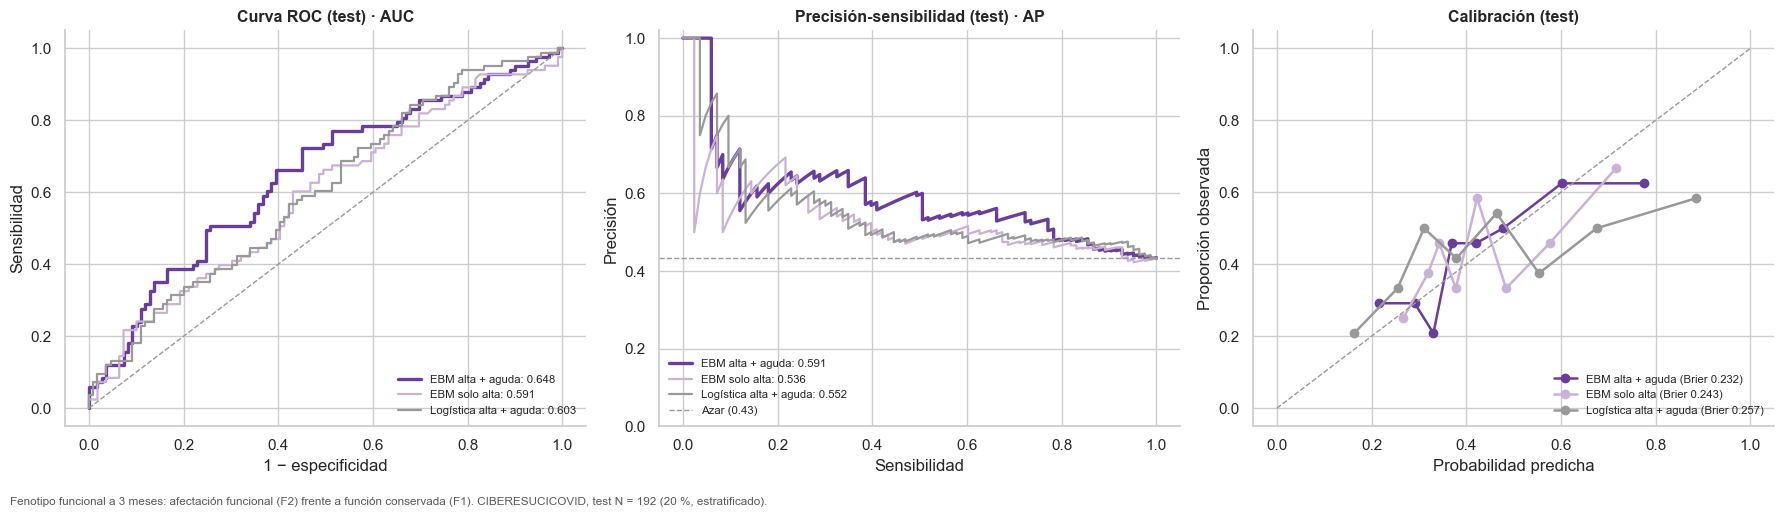

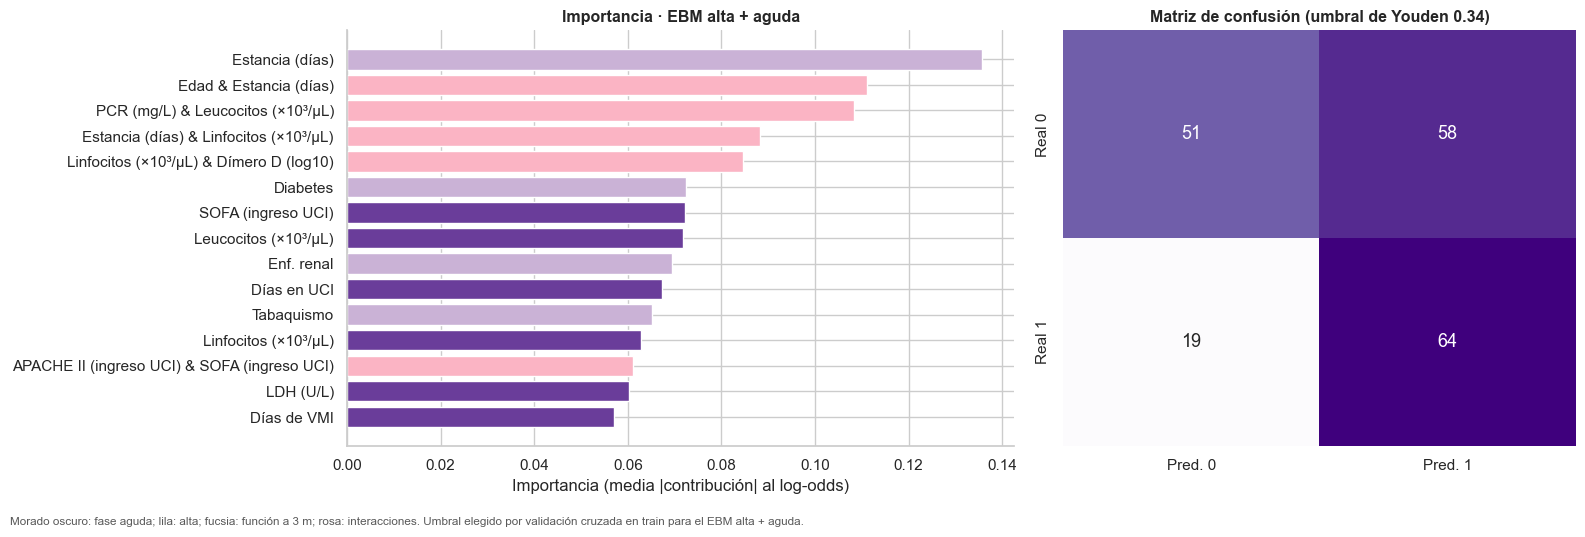

In [5]:
figuras(rA)

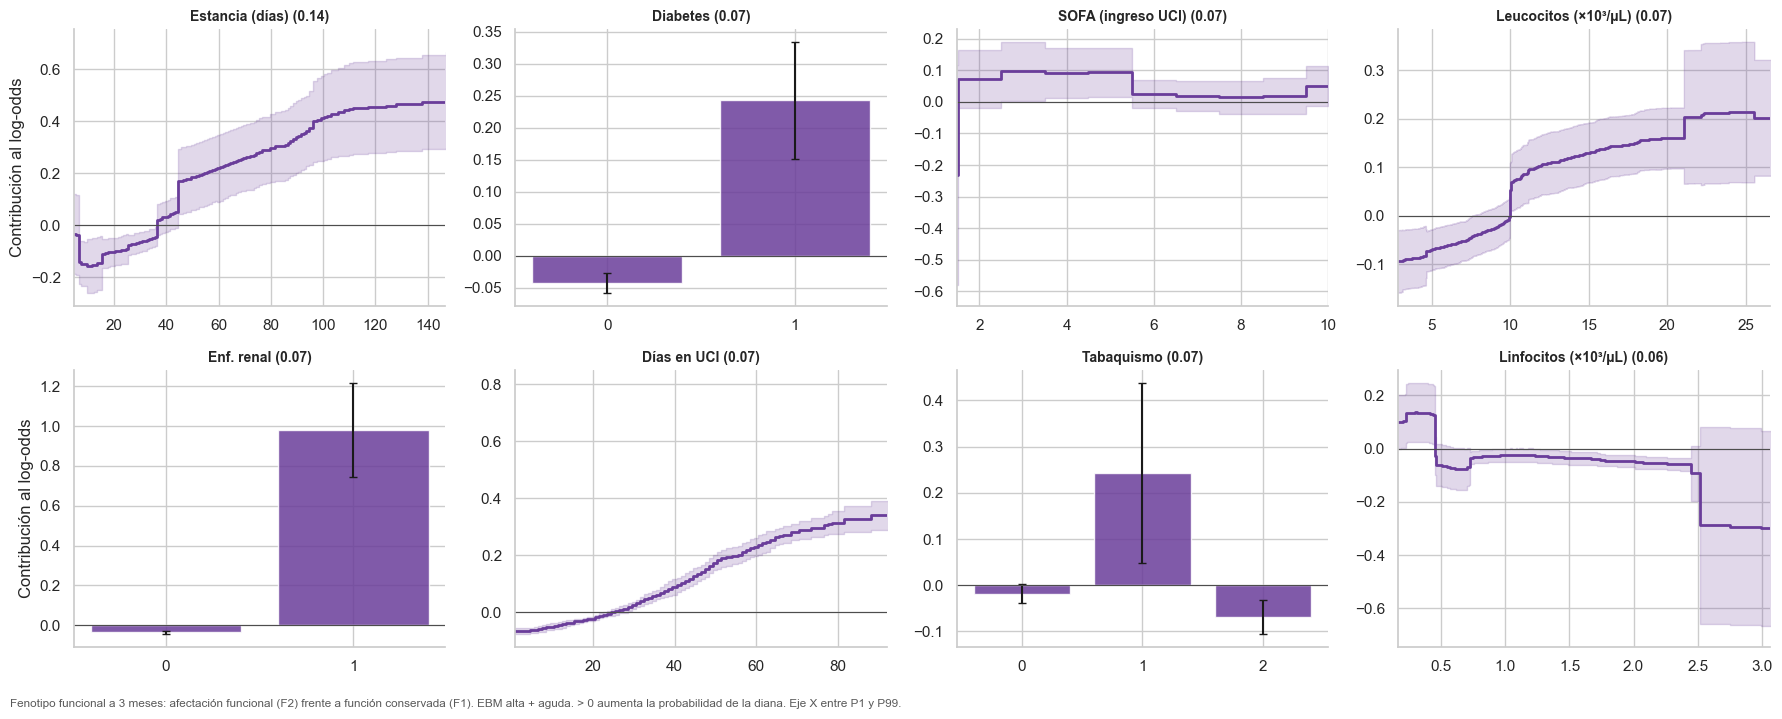

In [6]:
formas(rA)

In [7]:
pd.DataFrame([{"comparación": f"EBM alta + aguda − {otro}",
               **dict(zip(["Δ AUC", "IC95", "p"], (lambda d: (round(d[0], 3), f"{d[1][0]:+.3f} a {d[1][1]:+.3f}", round(d[2], 3)))(
                   dif_auc(rA["yte"], rA["P"]["EBM alta + aguda"], rA["P"][otro]))))}
              for otro in ["EBM solo alta", "Logística alta + aguda"]]).set_index("comparación")

,Δ AUC,IC95,p
comparación,,,
EBM alta + aguda − EBM solo alta,0.056,-0.007 a +0.120,0.078
EBM alta + aguda − Logística alta + aguda,0.044,-0.016 a +0.104,0.164


## 4 · Diana B · DLCO < 80 % a 12 meses

Desenlace clínico directo al año. Además del modelo con alta + aguda, se prueba añadiendo la **función pulmonar de la visita de 3 meses**. En la práctica sería un modelo "a los 3 meses" para predecir el año.

In [8]:
rB = analizar("dlco_12m")
print(f"N = {len(rB['ytr']) + len(rB['yte'])} (train {len(rB['ytr'])} / test {len(rB['yte'])}); % DLCO < 80 = {100 * rB['yte'].mean():.1f}; "
      f"{rB['n_centros']} centros.  * con el umbral de Youden ({rB['umbral']:.2f})")
rB["tabla"]

N = 473 (train 378 / test 95); % DLCO < 80 = 61.1; 35 centros.  * con el umbral de Youden (0.55)


,ROC-AUC,IC95,PR-AUC,Brier,Sensibilidad*,Especificidad*,AUC centros no vistos (media),(rango)
EBM alta + aguda,0.603,0.475–0.719,0.724,0.236,0.724,0.405,0.546,0.43–0.61
EBM solo alta,0.564,0.442–0.673,0.699,0.237,0.759,0.243,0.606,0.56–0.65
Logística alta + aguda,0.696,0.584–0.798,0.802,0.214,0.741,0.568,0.627,0.55–0.69
EBM alta + aguda + función 3 m,0.714,0.587–0.818,0.771,0.199,0.81,0.486,0.657,0.56–0.72


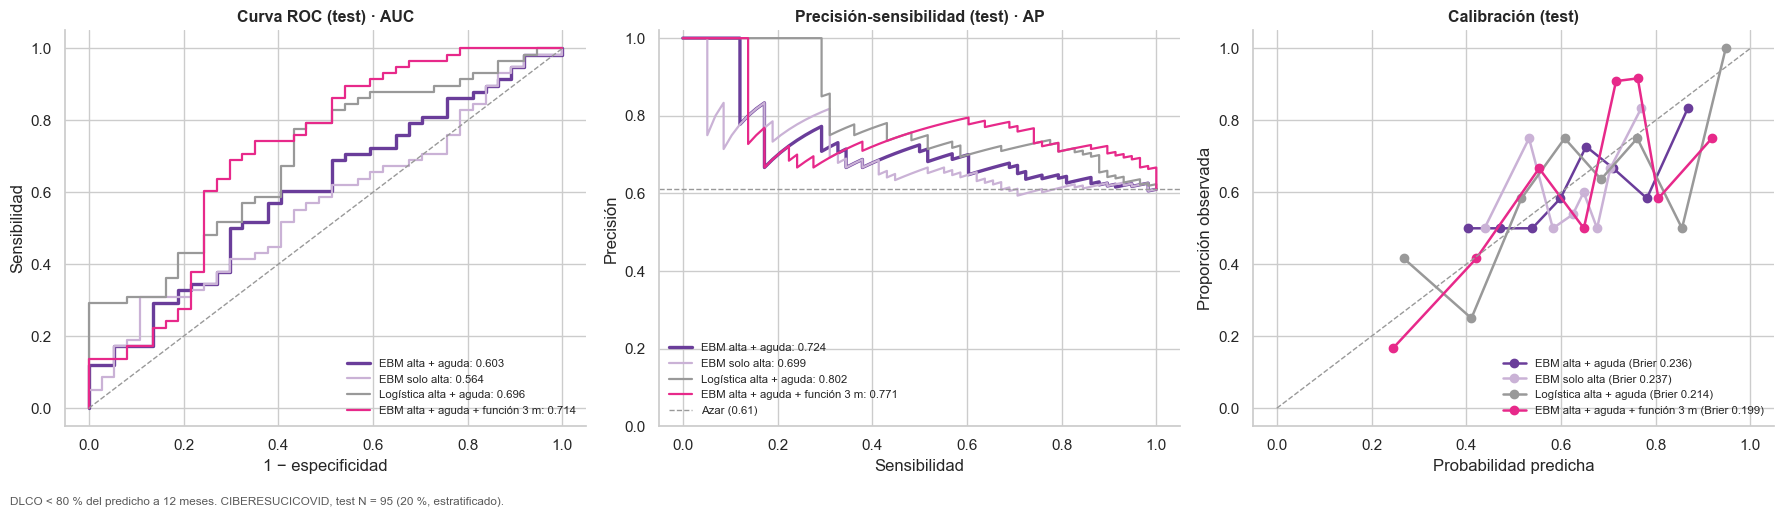

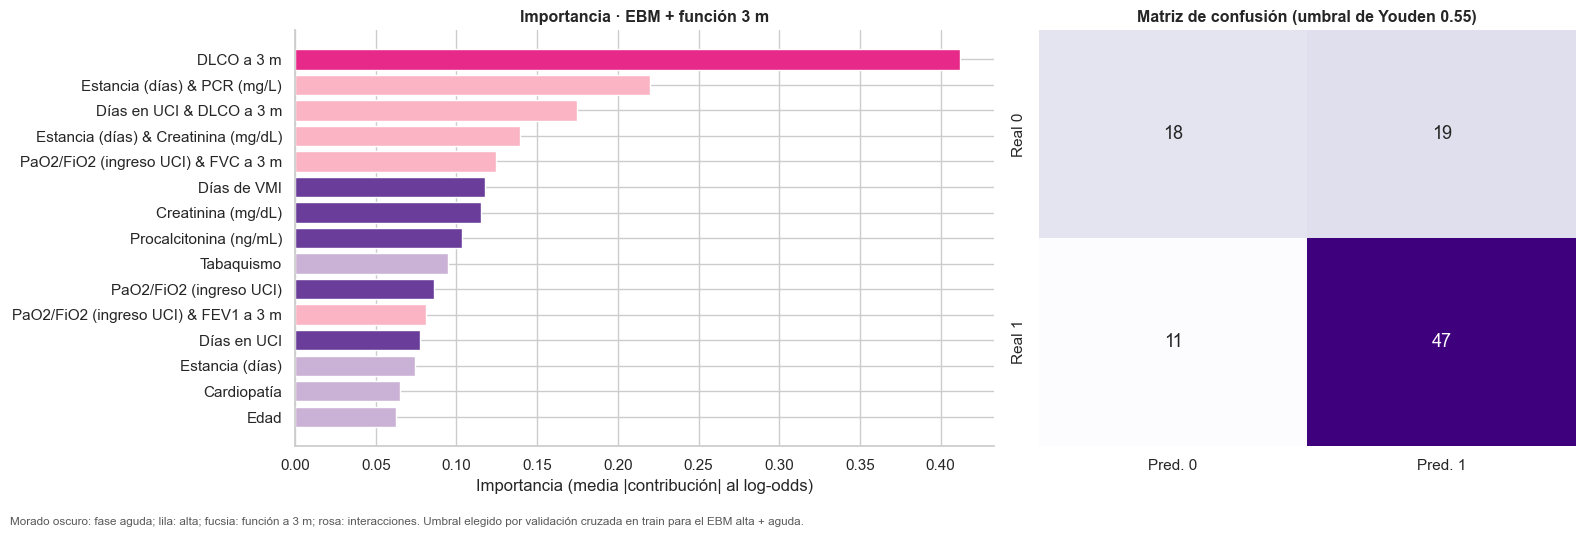

In [9]:
figuras(rB)

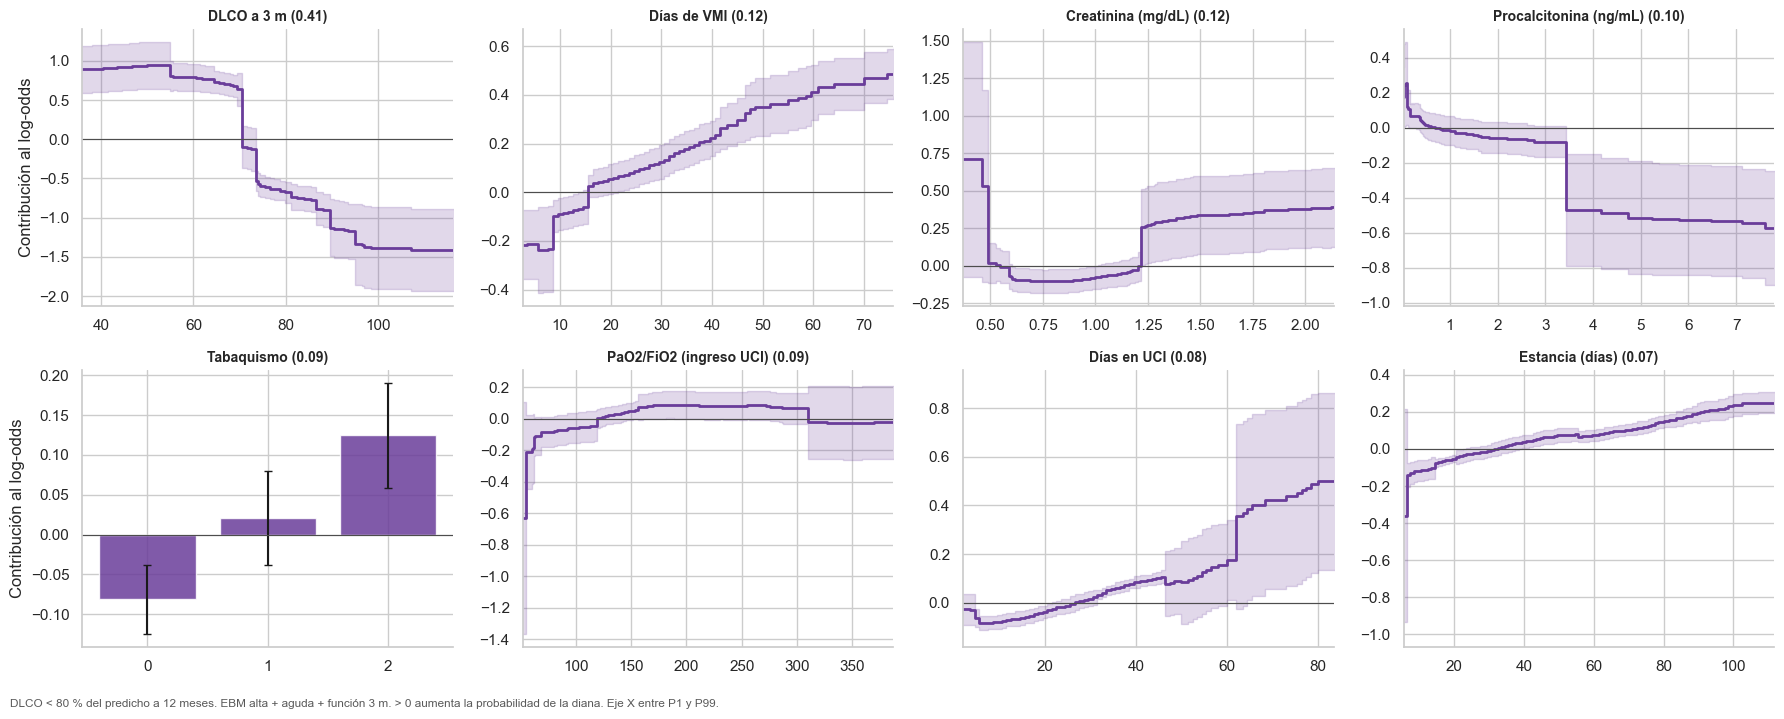

In [10]:
formas(rB, 'EBM alta + aguda + función 3 m')

In [11]:
pd.DataFrame([{"comparación": f"{a} − {b}",
               **dict(zip(["Δ AUC", "IC95", "p"], (lambda d: (round(d[0], 3), f"{d[1][0]:+.3f} a {d[1][1]:+.3f}", round(d[2], 3)))(
                   dif_auc(rB["yte"], rB["P"][a], rB["P"][b]))))}
              for a, b in [("EBM alta + aguda", "EBM solo alta"), ("EBM alta + aguda + función 3 m", "EBM alta + aguda")]]
             ).set_index("comparación")

,Δ AUC,IC95,p
comparación,,,
EBM alta + aguda − EBM solo alta,0.039,-0.061 a +0.136,0.440
EBM alta + aguda + función 3 m − EBM alta + aguda,0.111,+0.020 a +0.200,0.016


## 5 · Comparación con el modelo al alta (notebook 06)

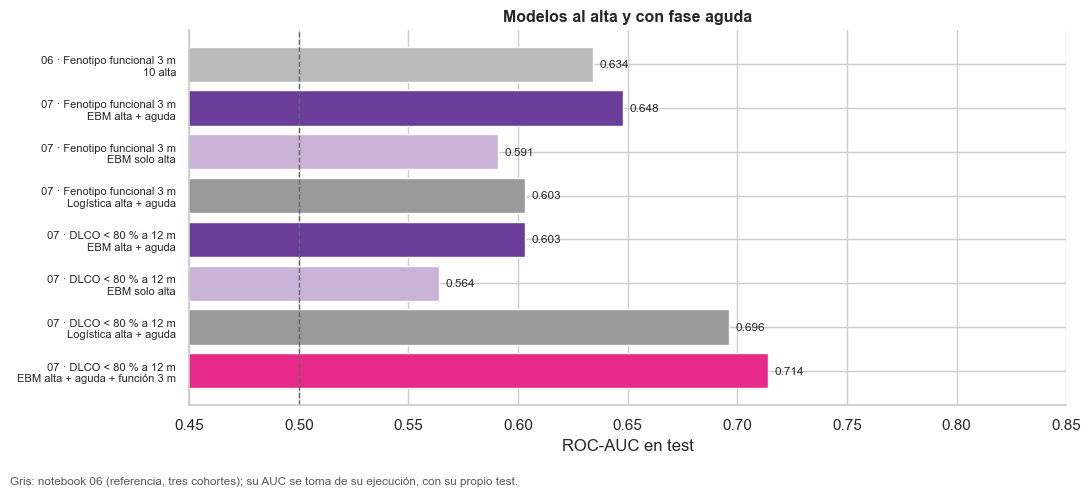

,notebook,cohorte(s),diana,predictores,AUC test,AUC centros no vistos
0,06,3 cohortes,Fenotipo funcional 3 m,10 alta,0.634,NaN
1,07,CIBERESUCICOVID,Fenotipo funcional 3 m,EBM alta + aguda,0.648,0.628
2,07,CIBERESUCICOVID,Fenotipo funcional 3 m,EBM solo alta,0.591,0.636
3,07,CIBERESUCICOVID,Fenotipo funcional 3 m,Logística alta + aguda,0.603,0.654
4,07,CIBERESUCICOVID,DLCO < 80 % a 12 m,EBM alta + aguda,0.603,0.546
5,07,CIBERESUCICOVID,DLCO < 80 % a 12 m,EBM solo alta,0.564,0.606
6,07,CIBERESUCICOVID,DLCO < 80 % a 12 m,Logística alta + aguda,0.696,0.627
7,07,CIBERESUCICOVID,DLCO < 80 % a 12 m,EBM alta + aguda + función 3 m,0.714,0.657


In [12]:
filas = [
    {"notebook": "06", "cohorte(s)": "3 cohortes", "diana": "Fenotipo funcional 3 m", "predictores": "10 alta", "AUC test": 0.634},
]
for r, diana in [(rA, "Fenotipo funcional 3 m"), (rB, "DLCO < 80 % a 12 m")]:
    for nombre in r["P"]:
        filas.append({"notebook": "07", "cohorte(s)": "CIBERESUCICOVID", "diana": diana, "predictores": nombre,
                      "AUC test": float(r["tabla"].loc[nombre, "ROC-AUC"]),
                      "AUC centros no vistos": float(r["tabla"].loc[nombre, "AUC centros no vistos (media)"])})
comparacion = pd.DataFrame(filas)
comparacion.to_csv(TAB / f"{PFX}_comparacion_modelos.csv", index=False)
pd.concat([rA["tabla"].assign(diana="A · fenotipo funcional 3 m"), rB["tabla"].assign(diana="B · DLCO < 80 % 12 m")]) \
    .to_csv(TAB / f"{PFX}_metricas_test.csv")

fig, ax = plt.subplots(figsize=(11, 4.8))
etq = comparacion["notebook"] + " · " + comparacion["diana"] + "\n" + comparacion["predictores"]
colores = ["#bbbbbb"] + [C_MOD.get(p, "#6a3d9a") for p in comparacion["predictores"][1:]]
ax.barh(etq, comparacion["AUC test"], color=colores)
for i, v in enumerate(comparacion["AUC test"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=8.5)
ax.axvline(0.5, color="0.4", ls="--", lw=1); ax.set_xlim(0.45, max(0.85, comparacion["AUC test"].max() + 0.05))
ax.invert_yaxis(); ax.tick_params(axis="y", labelsize=8); ax.set_xlabel("ROC-AUC en test")
ax.set_title("Modelos al alta y con fase aguda")
nota(fig, "Gris: notebook 06 (referencia, tres cohortes); su AUC se toma de su ejecución, con su propio test.")
plt.tight_layout(); guardar(fig, "comparacion_global"); plt.show()
comparacion

## 6 · Guardar

In [13]:
with open(DATOS / "modelos_ebm_ciberes_funcional.pkl", "wb") as f:
    pickle.dump({r["clave"]: {"modelos": {n: m for n, (m, _) in r["modelos"].items()},
                              "predictores": {n: c for n, (_, c) in r["modelos"].items()}, "umbral_youden": r["umbral"]}
                 for r in (rA, rB)}, f)
print(f"Modelos guardados en {DATOS.name}/modelos_ebm_ciberes_funcional.pkl (fuera del repositorio)")

Modelos guardados en Datos limpios/modelos_ebm_ciberes_funcional.pkl (fuera del repositorio)


## 7 · Resumen

**Resultados (ejecución con semilla 2026).**

**Diana A · fenotipo funcional a 3 meses (N = 956; test 192)**
- **EBM alta + aguda:** AUC **0,648** [0,571–0,728]. Es el mejor AUC de test para esta diana de todo el proyecto (notebook 06: 0,634 con 3 cohortes y solo el alta).
- **Frente al EBM solo alta (0,591):** la fase aguda suma +0,056 [−0,007 a +0,120], p = 0,08. Es una mejora **probable pero no demostrada**.
- **En centros no vistos la ventaja desaparece:** 0,63 (alta + aguda), 0,64 (solo alta) y 0,65 (logística). Con 41 centros, la estimación realista ronda **0,63–0,65** con cualquier conjunto de predictores.
- **Qué usa:** estancia hospitalaria (y su interacción con la edad), marcadores inflamatorios (PCR × leucocitos, linfocitos, dímero D), SOFA, días de UCI y de VMI, diabetes y enfermedad renal. Encaja con la gravedad del episodio.

**Diana B · DLCO < 80 % a 12 meses (N = 473; test 95)**
- **Con alta + aguda:** EBM AUC 0,603 [0,48–0,72] y logística 0,696. Con solo 378 pacientes de entrenamiento, el EBM con interacciones **se sobreajusta** y la logística, más simple, funciona mejor. Los IC son muy anchos.
- **Añadiendo la función a 3 meses** (DLCO, FVC y FEV1 de la primera visita), el EBM sube a **AUC 0,714** [0,587–0,818], **+0,111 [+0,020 a +0,200], p = 0,016**. Es la única mejora significativa de este notebook, y se mantiene en centros no vistos (0,66).
- **El predictor dominante es la DLCO a 3 meses**, seguida de interacciones de la estancia con la inflamación (PCR, creatinina) y de la PaO2/FiO2 con la FVC a 3 meses.

**Conclusiones de los modelos al alta (notebooks 06 y 07)**
1. **Al alta, el techo es un AUC de ≈ 0,63–0,65** para el estado funcional, con o sin fase aguda y con cualquier modelo probado (logística o EBM). La fase aguda de CIBERESUCICOVID aporta poco y no de forma robusta entre centros.
2. **Lo que de verdad predice el año es la función a 3 meses.** Un modelo "en la primera visita" (AUC ≈ 0,71) es más útil que uno "al alta" (≈ 0,63). Para el uso clínico: **la primera espirometría y DLCO son el momento clave para estratificar** el seguimiento. El notebook 08 lo retoma con las tres cohortes: la DLCO a 3 meses sola ya da un AUC de 0,79–0,87 dejando fuera cada cohorte.
3. **Muestras pequeñas** (diana B: 95 pacientes de test). Los IC son anchos y los modelos simples (logística) compiten bien con el EBM: hay que priorizar modelos parsimoniosos y validar entre centros.